# Suite No. 3 — Scale-Dependent Low-Frequency Structure in Proxy Field Readouts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HNXJ/jaxfne/blob/main/tutorials/jaxfne_suite_no_3_low_frequency_scaling.ipynb)

**Tutorial type:** `jaxfne` / TFNE tutorial atlas notebook  
**Execution target:** Antigravity or Colab-style notebook runner  
**Canonical import:** `import jaxfne as jtfne`  
**Truth status:** `truth_safe_unverified` / `computational_scaffold`  
**Readout status:** simulated/proxy readouts; no calibrated physical amplitude interpretation  

This suite tests the scaling hypothesis that low-frequency content in simulated/proxy field readouts changes with modeled population size or declared spatial extent. The analysis treats low-frequency divergence as a scale-sensitive interpretation boundary for finite proxy readouts.

Antigravity execution contract:

1. Run all cells from a clean environment or project checkout.
2. Use the package as the simulation engine.
3. Do not add a local simulator loop to the notebook.
4. If a required public API is missing, patch `jaxfne` first, then rerun the notebook.
5. Save the executed notebook and export HTML after figures are visible in cell outputs.

Suggested export command after execution:

```bash
jupyter nbconvert --to html --execute suite_no3_low_frequency_scaling_proxy_readouts.ipynb
```

## 1. Learning objectives

By the end of this suite, you should be able to:

1. Explain why low-frequency proxy readouts are more sensitive to spatial scale and source coherence than local spike statistics.
2. Distinguish nonlinear emitter/network generation from linear source-to-probe projection.
3. Run a package-default scaling experiment across multiple population sizes.
4. Compute bandpower ratios and synchrony proxies from simulated/proxy readouts.
5. Export figures, manifest metadata, and validation summaries without calibrated physical amplitude claims.

## 2. Biological/computational question

**Question:** How does increasing the modeled neural population or declared spatial extent alter low-frequency structure in simulated/proxy field readouts?

**Working hypothesis:** Larger modeled support can preserve slow coherent source modes in aggregate readouts, while faster local fluctuations are more likely to average out under projection. This does not identify a biological mechanism by itself; it gives a controlled computational diagnostic for scale-sensitive readout behavior.

## 3. Mathematical glossary flow

### Formal equation

$$
Y_c(t) = \sum_{n=1}^{N} W_{cn} S_n(t)
$$

### Terms

| Symbol | Meaning | Status in this suite |
|---|---|---|
| $Y_c(t)$ | readout at channel/contact $c$ and time $t$ | simulated/proxy readout |
| $W_{cn}$ | projection weight from source element $n$ to channel/contact $c$ | declared or package-default proxy projection |
| $S_n(t)$ | source feature from neuron/source element $n$ | standard/proxy source feature |
| $N$ | number of source elements | varied across scales |
| $c$ | readout channel/contact index | package/readout dependent |

### Worded equation

The channel signal is the weighted sum of source activity across the modeled source population.

### Implementation location

This notebook expects the package path:

```text
Configuration -> construct -> simulate -> probe/readout -> metrics/figures
```

### Scope boundary

This is a proxy source-to-readout projection unless a run supplies physical geometry, calibrated source units, conductivity, boundary conditions, gauge handling, a physical field solver, and validation evidence.

## 4. Install and import

For Antigravity on the project checkout, the editable repository can provide `jaxfne`. For Colab or a clean environment, the install cell can pin the public tutorial-atlas baseline.

In [1]:
# Colab/public path. In an editable Antigravity checkout, this cell can be skipped.
# The v0.3.4 line is the current tutorial-atlas grammar baseline for Suite No. 3.
%pip install -q "jaxfne==0.3.4"



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/hamednejat/workspace/main/jaxfne/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
from importlib import metadata as importlib_metadata
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jaxfne as jtfne

try:
    JAXFNE_VERSION = importlib_metadata.version("jaxfne")
except importlib_metadata.PackageNotFoundError:
    JAXFNE_VERSION = getattr(jtfne, "__version__", "unknown")

print("jaxfne version:", JAXFNE_VERSION)
print("jax version:", jax.__version__)
print("python:", sys.version.split()[0])
print("platform:", platform.platform())
print("devices:", jax.devices())


jaxfne version: 0.3.4
jax version: 0.10.0
python: 3.14.4
platform: macOS-26.5-arm64-arm-64bit-Mach-O
devices: [CpuDevice(id=0)]


## 5. Configuration block

The hard tutorial gates are declared here. The default scale list is CPU-conscious; set `ENABLE_N_1000 = True` for a heavier Antigravity run.

In [3]:
SEED = 303
DURATION_MS = 1000.0
DT_MS = 0.1
DTYPE = "float32"
DX_MM = DY_MM = DZ_MM = 0.010

BASE_SCALES = [10, 50, 100, 500]
ENABLE_N_1000 = False
SCALES = BASE_SCALES + ([1000] if ENABLE_N_1000 else [])

E_FRACTION = 0.75
I_FRACTION = 0.25
LAYER_NAMES = ["L2/3", "L4", "L5", "L6"]
PROBE_MODES = ["spk", "vm", "source", "lfp_like", "eeg_like"]

LOW_BAND_HZ = (0.5, 4.0)
MID_BAND_HZ = (4.0, 12.0)
HIGH_BAND_HZ = (30.0, 80.0)
SYNCHRONY_BIN_MS = 10.0

OUTPUT_DIR = Path("outputs") / "suite_no3_low_frequency_scaling"
FIG_DIR = OUTPUT_DIR / "figures"
PLOTLY_DIR = OUTPUT_DIR / "plotly"
for path in [OUTPUT_DIR, FIG_DIR, PLOTLY_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("scales:", SCALES)
print("output_dir:", OUTPUT_DIR.resolve())


scales: [10, 50, 100, 500]
output_dir: /Users/hamednejat/workspace/main/jaxfne/tutorials/outputs/suite_no3_low_frequency_scaling


## 6. Package API guard

This cell checks that the notebook can use `jaxfne` as the engine. The notebook intentionally does not contain a fallback dynamics engine. If this guard stops, add the missing public API to `jaxfne` or adapt this notebook to the actual public grammar without moving simulator logic into notebook cells.

In [4]:
def require_public_api() -> None:
    required_root = ["Configuration", "construct", "simulate"]
    missing_root = [name for name in required_root if not hasattr(jtfne, name)]
    if missing_root:
        raise RuntimeError(
            "Missing required jaxfne public API symbols: "
            + ", ".join(missing_root)
            + ". Patch the package public API before running Suite No. 3."
        )

    cfg = jtfne.Configuration()
    required_cfg_methods = ["runtime", "column", "cell_types", "connectivity", "set_emitter", "probes"]
    missing_cfg = [name for name in required_cfg_methods if not hasattr(cfg, name)]
    if missing_cfg:
        raise RuntimeError(
            "Missing required Configuration methods: "
            + ", ".join(missing_cfg)
            + ". Do not add local dynamics to this notebook; patch the package."
        )

require_public_api()
print("Public API guard passed.")


Public API guard passed.


## 7. Simulation block

The orchestration helper below constructs one package-default model per scale. It may contain metadata and method calls, but it does not implement the neural dynamics. All dynamics must come from `jaxfne`.

In [5]:
def build_scale_configuration(n: int, seed: int):
    """Build a package-native scale configuration.

    This function is orchestration only. It must not implement emitter, synapse,
    field, or probe dynamics.
    """
    n_e = int(round(E_FRACTION * n))
    n_i = n - n_e
    extent_mm = float((n / min(SCALES)) ** (1.0 / 3.0))  # declared metadata, not a solved PDE grid

    cfg = jtfne.Configuration()
    cfg = cfg.runtime(device="auto", dtype=DTYPE, x64_enabled=False, seed=seed)
    cfg = cfg.column(
        name=f"suite03_scale_{n}",
        layers=LAYER_NAMES,
        n=n,
    )
    cfg = cfg.cell_types({"E": n_e, "PV": n_i})
    cfg = cfg.connectivity(
        kind="recurrent_ei",
        density="matched_across_scales",
        ei_fraction={"E": E_FRACTION, "PV": I_FRACTION},
        seed=seed,
        source_projection_mode="proxy_projection",
    )
    cfg = cfg.emitter(
        family="izhikevich",
        preset="regular_spiking_and_fast_spiking_ei",
        drive_mode="matched_safe_rate",
        target_rate_hz=(2.0, 25.0),
        seed=seed,
    )
    cfg = cfg.probes(
        PROBE_MODES,
        field_solver_status="laminar_proxy_no_pde",
        source_calibration_status="uncalibrated_spike_only",
        physical_amplitude_claim_allowed=False,
        CSD_sign_convention="positive_equals_extracellular_source",
    )
    return cfg


def construct_and_simulate(cfg, seed: int):
    """Run construct/simulate through jaxfne public calls."""
    model = jtfne.construct(cfg)

    # Prefer a Simulation object/factory when present; otherwise use root simulate kwargs.
    if hasattr(jtfne, "simulation"):
        sim = jtfne.simulation(duration_ms=DURATION_MS, dt_ms=DT_MS, seed=seed)
        signals = jtfne.simulate(model, sim)
    elif hasattr(jtfne, "Simulation"):
        sim = jtfne.Simulation(duration_ms=DURATION_MS, dt_ms=DT_MS, seed=seed)
        signals = jtfne.simulate(model, sim)
    else:
        signals = jtfne.simulate(model, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=seed)

    # Probe via model method if available; otherwise accept signals with embedded readouts.
    if hasattr(model, "probe"):
        readout = model.probe(signals)
    elif hasattr(jtfne, "probe"):
        readout = jtfne.probe(model, signals)
    else:
        readout = signals

    return model, signals, readout

## 8. Probe/readout extraction block

This block extracts public arrays from package outputs for tutorial analysis. It performs type conversion and shape checks only.

In [6]:
def _to_numpy(x: Any) -> np.ndarray | None:
    if x is None:
        return None
    try:
        arr = np.asarray(x)
    except Exception:
        return None
    if arr.dtype == object:
        return None
    return arr


def _get_from_object(obj: Any, names: list[str]) -> Any:
    if obj is None:
        return None
    if isinstance(obj, dict):
        for name in names:
            if name in obj:
                return obj[name]
        for key in ["readouts", "probes", "signals", "data", "outputs"]:
            if key in obj:
                found = _get_from_object(obj[key], names)
                if found is not None:
                    return found
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)
    for attr in ["readouts", "probes", "signals", "data", "outputs"]:
        if hasattr(obj, attr):
            found = _get_from_object(getattr(obj, attr), names)
            if found is not None:
                return found
    return None


def extract_suite_arrays(signals: Any, readout: Any) -> dict[str, np.ndarray]:
    candidates = [readout, signals]
    aliases = {
        "spikes": ["spikes", "spike_matrix", "spk", "spk_matrix", "spike_train"],
        "vm": ["vm", "Vm", "voltage", "v", "membrane_voltage"],
        "source": ["source", "source_proxy", "S", "sources", "source_trace"],
        "lfp_like": ["lfp_like", "lfp", "lfp_proxy", "Y_lfp", "readout_lfp_like"],
        "eeg_like": ["eeg_like", "eeg_proxy", "Y_eeg", "readout_eeg_like"],
    }
    out: dict[str, np.ndarray] = {}
    for canonical, names in aliases.items():
        for obj in candidates:
            value = _get_from_object(obj, names)
            arr = _to_numpy(value)
            if arr is not None:
                out[canonical] = arr
                break
    if "lfp_like" not in out and "source" in out:
        # This is not a field solver. It is a source-summary proxy used only when the package
        # returns source but not a named lfp_like readout. Keep the manifest explicit.
        src = np.asarray(out["source"])
        out["lfp_like"] = src.mean(axis=-1) if src.ndim >= 2 else src
    return out


def assert_finite_array(name: str, arr: np.ndarray) -> None:
    if not np.all(np.isfinite(arr)):
        raise ValueError(f"{name} contains non-finite values.")
    if np.max(np.abs(arr)) > 1e12:
        raise ValueError(f"{name} contains astronomical proxy values.")


## 9. Metrics block

Metrics use relative proxy spectra and ratios. They avoid interpreting arbitrary readout amplitude as a calibrated physical field.

In [7]:
def _trapz(y, x):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return _trapz(y, x)


def one_dimensional_readout(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 1:
        y = arr
    elif arr.ndim == 2:
        # Accept either [T, C] or [C, T]; choose the dimension closest to the expected time length.
        expected_t = int(round(DURATION_MS / DT_MS))
        if abs(arr.shape[0] - expected_t) <= abs(arr.shape[1] - expected_t):
            y = arr.mean(axis=1)
        else:
            y = arr.mean(axis=0)
    else:
        y = arr.reshape(arr.shape[0], -1).mean(axis=1)
    y = y - np.mean(y)
    return y


def compute_psd(y: np.ndarray, dt_ms: float) -> tuple[np.ndarray, np.ndarray]:
    y = np.asarray(y, dtype=np.float64)
    if y.size < 8:
        raise ValueError("Readout is too short for PSD estimation.")
    fs = 1000.0 / dt_ms
    window = np.hanning(y.size)
    yw = (y - np.mean(y)) * window
    scale = np.sum(window**2) * fs
    spec = np.abs(np.fft.rfft(yw)) ** 2 / max(scale, np.finfo(float).eps)
    freq = np.fft.rfftfreq(y.size, d=1.0 / fs)
    return freq, spec


def bandpower(freq: np.ndarray, psd: np.ndarray, band: tuple[float, float]) -> float:
    lo, hi = band
    mask = (freq >= lo) & (freq < hi)
    if not np.any(mask):
        return float("nan")
    return float(_trapz(psd[mask], freq[mask]))


def estimate_mean_rate_hz(spikes: np.ndarray, n: int) -> float:
    spikes = np.asarray(spikes)
    if spikes.ndim == 1:
        spike_count = float(np.sum(spikes > 0))
    else:
        spike_count = float(np.sum(spikes > 0))
    duration_s = DURATION_MS / 1000.0
    return spike_count / max(n * duration_s, np.finfo(float).eps)


def synchrony_proxy_from_spikes(spikes: np.ndarray, bin_ms: float = SYNCHRONY_BIN_MS) -> float:
    spikes = np.asarray(spikes)
    if spikes.ndim == 1:
        return float("nan")
    # Standardize to [T, N].
    expected_t = int(round(DURATION_MS / DT_MS))
    if spikes.shape[0] != expected_t and spikes.shape[1] == expected_t:
        spikes = spikes.T
    bin_size = max(1, int(round(bin_ms / DT_MS)))
    n_bins = spikes.shape[0] // bin_size
    if n_bins < 2:
        return float("nan")
    trimmed = spikes[: n_bins * bin_size]
    binned_population_counts = trimmed.reshape(n_bins, bin_size, -1).sum(axis=(1, 2))
    mean_count = np.mean(binned_population_counts)
    return float(np.var(binned_population_counts) / (mean_count + np.finfo(float).eps))


def json_safe(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return json_safe(obj.tolist())
    if isinstance(obj, (np.floating, float)):
        v = float(obj)
        return v if math.isfinite(v) else None
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if obj is None or isinstance(obj, str):
        return obj
    return str(obj)

## 10. Run the scaling experiment

This loop executes one package-default run per scale and exports the core arrays needed for figures and validation.

In [8]:
results: dict[int, dict[str, Any]] = {}
validation_records: list[dict[str, Any]] = []

for index, n in enumerate(SCALES):
    scale_seed = SEED + 1000 * index
    print(f"Running scale N={n}, seed={scale_seed}")
    cfg = build_scale_configuration(n=n, seed=scale_seed)
    model, signals, readout = construct_and_simulate(cfg, seed=scale_seed)
    arrays = extract_suite_arrays(signals, readout)

    if "lfp_like" not in arrays:
        raise RuntimeError(f"N={n}: missing lfp_like/source-derived proxy readout.")

    for name, arr in arrays.items():
        assert_finite_array(f"N={n}:{name}", arr)

    y = one_dimensional_readout(arrays["lfp_like"])
    freq, psd = compute_psd(y, DT_MS)
    low_power = bandpower(freq, psd, LOW_BAND_HZ)
    mid_power = bandpower(freq, psd, MID_BAND_HZ)
    high_power = bandpower(freq, psd, HIGH_BAND_HZ)
    low_high_ratio = low_power / max(high_power, np.finfo(float).eps)

    mean_rate_hz = None
    synchrony_proxy = None
    if "spikes" in arrays:
        mean_rate_hz = estimate_mean_rate_hz(arrays["spikes"], n=n)
        synchrony_proxy = synchrony_proxy_from_spikes(arrays["spikes"])

    metrics = {
        "N": n,
        "seed": scale_seed,
        "mean_rate_hz": mean_rate_hz,
        "low_power_0p5_4_hz": low_power,
        "mid_power_4_12_hz": mid_power,
        "high_power_30_80_hz": high_power,
        "low_high_ratio": low_high_ratio,
        "synchrony_proxy": synchrony_proxy,
    }

    results[n] = {
        "cfg": cfg,
        "model": model,
        "signals": signals,
        "readout": readout,
        "arrays": arrays,
        "readout_1d": y,
        "freq": freq,
        "psd": psd,
        "metrics": metrics,
    }

    validation_records.append({
        "N": n,
        "arrays_present": sorted(arrays.keys()),
        "finite_outputs": True,
        "mean_rate_gate_2_25_hz": None if mean_rate_hz is None else (2.0 <= mean_rate_hz <= 25.0),
        "proxy_readout_only": True,
    })

print("Completed scales:", list(results.keys()))


Running scale N=10, seed=303


Running scale N=50, seed=1303


Running scale N=100, seed=2303


Running scale N=500, seed=3303


Completed scales: [10, 50, 100, 500]


## 11. Metrics table

Inspect the table before interpreting figures. A low-frequency increase paired with excessive synchrony should be treated as a synchrony regime rather than a clean spatial-scale effect.

In [9]:
try:
    import pandas as pd
    metrics_df = pd.DataFrame([results[n]["metrics"] for n in SCALES])
    display(metrics_df)
except Exception:
    metrics_df = None
    print(json.dumps(json_safe([results[n]["metrics"] for n in SCALES]), indent=2))


,N,seed,mean_rate_hz,low_power_0p5_4_hz,mid_power_4_12_hz,high_power_30_80_hz,low_high_ratio,synchrony_proxy
0,10,303,11.0,9.072593e-06,0.000365,0.001502,0.006039,6.172728
1,50,1303,11.0,8.597197e-07,0.000456,0.001621,0.000530,31.830910
2,100,2303,11.0,2.210314e-07,0.000470,0.001887,0.000117,63.434548
3,500,3303,11.0,1.777654e-07,0.000730,0.003224,0.000055,332.909446


## 12. Figures

All figure titles use proxy-safe terminology. PNG files are written to `outputs/suite_no3_low_frequency_scaling/figures/`.

saved outputs/suite_no3_low_frequency_scaling/figures/01_suite03_raster_by_scale.png


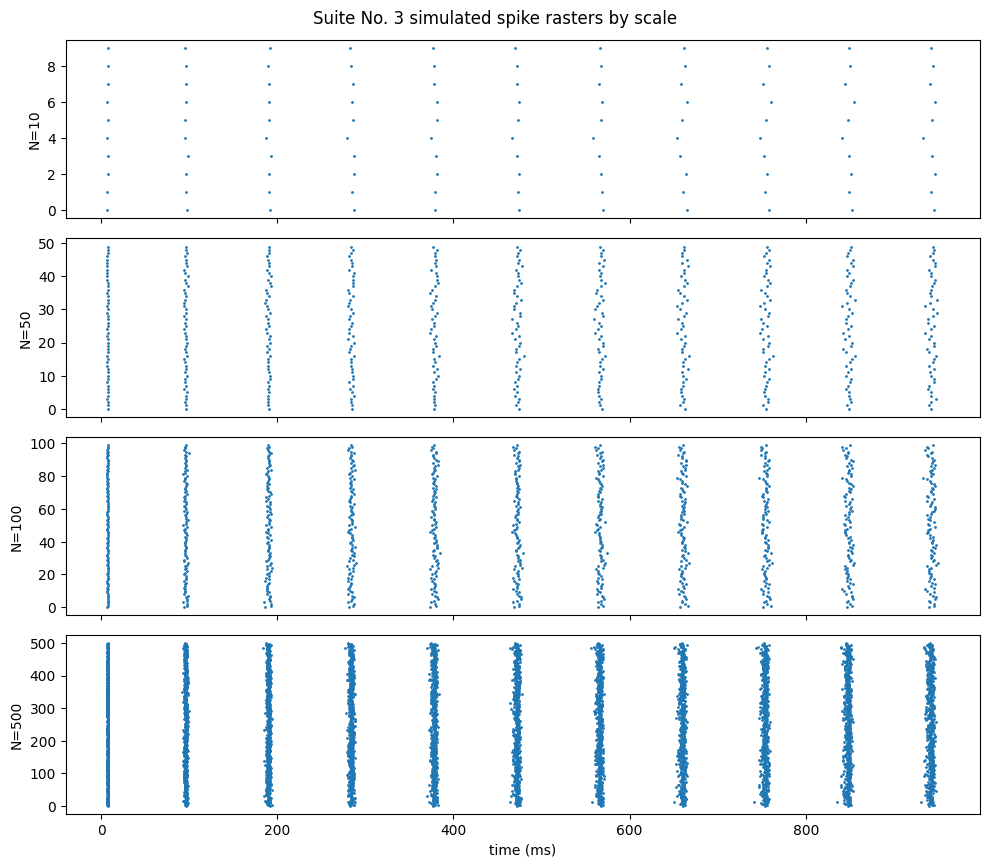

In [10]:
def save_current_figure(filename: str) -> Path:
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved", path)
    return path

# Figure 1: raster by scale when spike matrices are available.
fig, axes = plt.subplots(len(SCALES), 1, figsize=(10, max(3, 2.2 * len(SCALES))), sharex=True)
if len(SCALES) == 1:
    axes = [axes]
for ax, n in zip(axes, SCALES):
    spikes = results[n]["arrays"].get("spikes")
    if spikes is None:
        ax.text(0.5, 0.5, "spike matrix not returned", ha="center", va="center", transform=ax.transAxes)
        ax.set_ylabel(f"N={n}")
        continue
    spikes = np.asarray(spikes)
    expected_t = int(round(DURATION_MS / DT_MS))
    if spikes.ndim == 2 and spikes.shape[0] != expected_t and spikes.shape[1] == expected_t:
        spikes = spikes.T
    if spikes.ndim == 2:
        t_idx, neuron_idx = np.where(spikes > 0)
        ax.scatter(t_idx * DT_MS, neuron_idx, s=1)
    else:
        ax.plot(np.arange(spikes.size) * DT_MS, spikes)
    ax.set_ylabel(f"N={n}")
ax.set_xlabel("time (ms)")
fig.suptitle("Suite No. 3 simulated spike rasters by scale")
save_current_figure("01_suite03_raster_by_scale.png")
plt.show()


saved outputs/suite_no3_low_frequency_scaling/figures/02_suite03_proxy_readout_traces.png


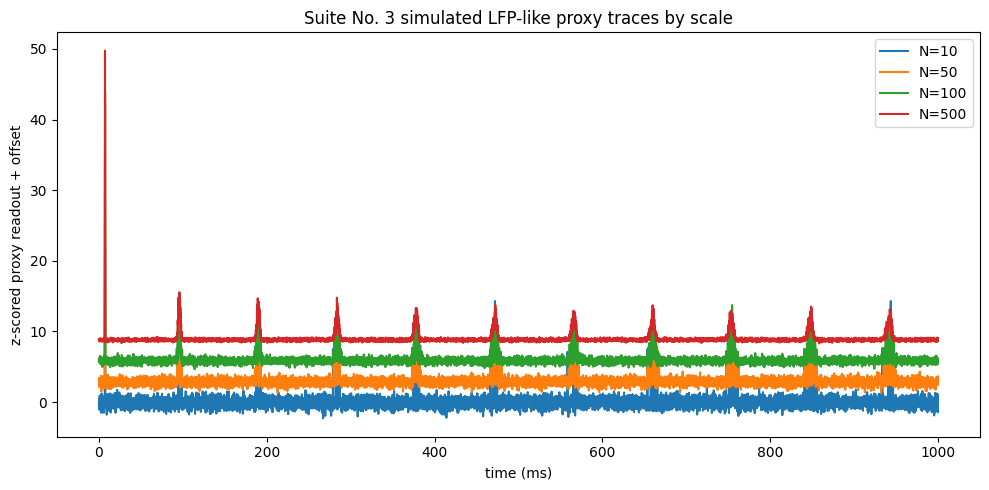

In [11]:
# Figure 2: proxy readout traces by scale.
plt.figure(figsize=(10, 5))
for n in SCALES:
    y = results[n]["readout_1d"]
    t_ms = np.arange(y.size) * DT_MS
    denom = np.std(y) + np.finfo(float).eps
    plt.plot(t_ms, (y - np.mean(y)) / denom + 3.0 * SCALES.index(n), label=f"N={n}")
plt.xlabel("time (ms)")
plt.ylabel("z-scored proxy readout + offset")
plt.title("Suite No. 3 simulated LFP-like proxy traces by scale")
plt.legend(loc="upper right")
save_current_figure("02_suite03_proxy_readout_traces.png")
plt.show()


saved outputs/suite_no3_low_frequency_scaling/figures/03_suite03_psd_by_scale.png


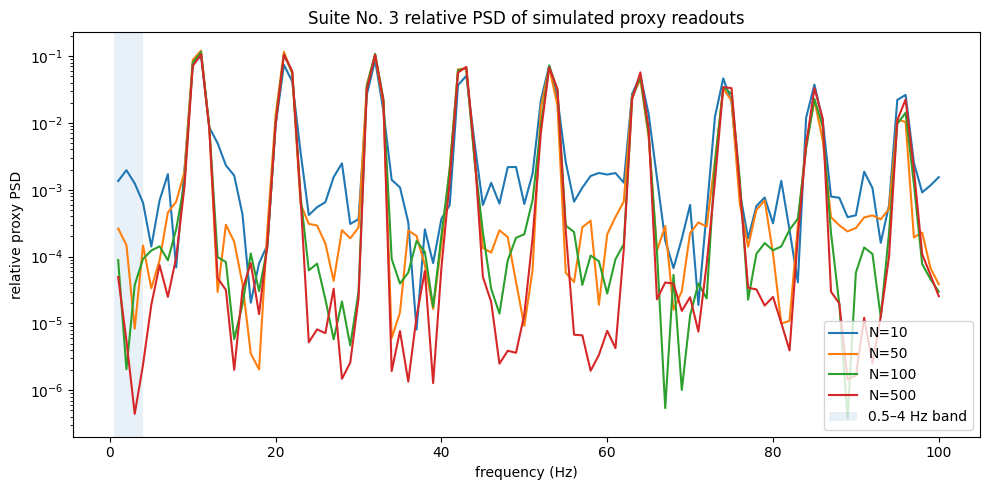

In [12]:
def _trapz(y, x):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return _trapz(y, x)

# Figure 3: PSD by scale.
plt.figure(figsize=(10, 5))
for n in SCALES:
    freq = results[n]["freq"]
    psd = results[n]["psd"]
    mask = (freq >= 0.5) & (freq <= 100.0)
    denom = _trapz(psd[mask], freq[mask]) + np.finfo(float).eps
    plt.semilogy(freq[mask], psd[mask] / denom, label=f"N={n}")
plt.axvspan(LOW_BAND_HZ[0], LOW_BAND_HZ[1], alpha=0.1, label="0.5–4 Hz band")
plt.xlabel("frequency (Hz)")
plt.ylabel("relative proxy PSD")
plt.title("Suite No. 3 relative PSD of simulated proxy readouts")
plt.legend(loc="best")
save_current_figure("03_suite03_psd_by_scale.png")
plt.show()

saved outputs/suite_no3_low_frequency_scaling/figures/04_suite03_low_high_ratio_vs_scale.png


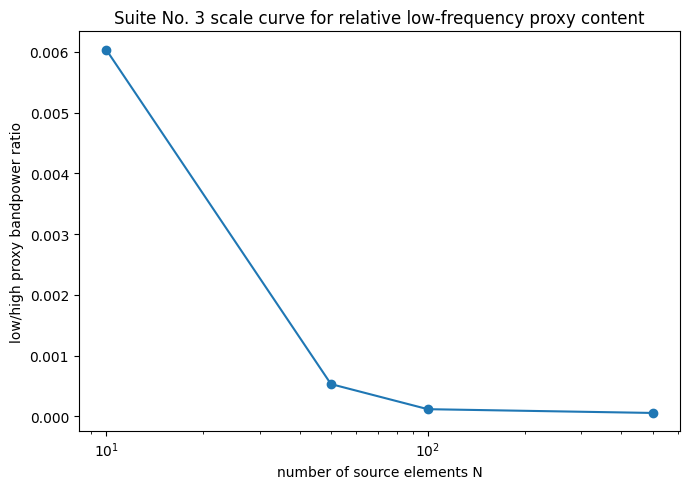

In [13]:
# Figure 4: low-frequency metrics versus scale.
Ns = np.array(SCALES, dtype=float)
low_powers = np.array([results[n]["metrics"]["low_power_0p5_4_hz"] for n in SCALES], dtype=float)
ratios = np.array([results[n]["metrics"]["low_high_ratio"] for n in SCALES], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(Ns, ratios, marker="o")
plt.xscale("log")
plt.xlabel("number of source elements N")
plt.ylabel("low/high proxy bandpower ratio")
plt.title("Suite No. 3 scale curve for relative low-frequency proxy content")
save_current_figure("04_suite03_low_high_ratio_vs_scale.png")
plt.show()


saved outputs/suite_no3_low_frequency_scaling/figures/05_suite03_synchrony_proxy_vs_scale.png


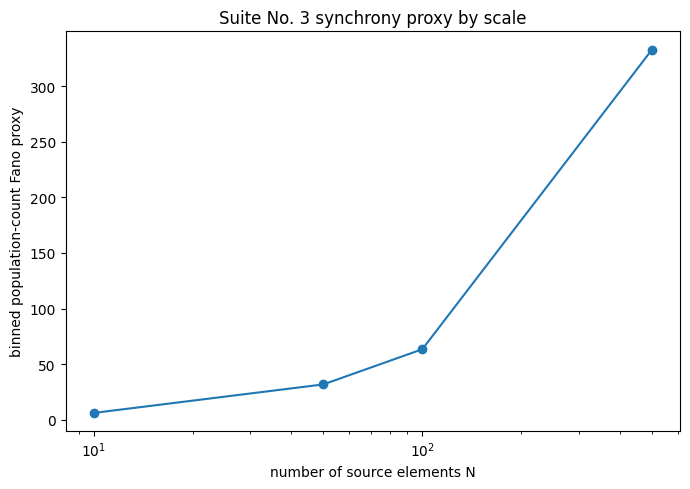

In [14]:
# Figure 5: synchrony proxy versus scale.
sync_values = np.array([
    np.nan if results[n]["metrics"]["synchrony_proxy"] is None else results[n]["metrics"]["synchrony_proxy"]
    for n in SCALES
], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(Ns, sync_values, marker="o")
plt.xscale("log")
plt.xlabel("number of source elements N")
plt.ylabel("binned population-count Fano proxy")
plt.title("Suite No. 3 synchrony proxy by scale")
save_current_figure("05_suite03_synchrony_proxy_vs_scale.png")
plt.show()


## 13. Manifest and verification records

The manifest records runtime, geometry metadata, source/readout status, and output assets. It is strict JSON-safe.

In [15]:
asset_hashes = {}
try:
    import hashlib
    for fig_path in sorted(FIG_DIR.glob("*.png")):
        asset_hashes[str(fig_path.relative_to(OUTPUT_DIR))] = hashlib.sha256(fig_path.read_bytes()).hexdigest()
except Exception as exc:
    print("asset hash warning:", exc)

manifest = {
    "suite": "suite_no3_low_frequency_scaling_proxy_readouts",
    "run_id": f"suite03_seed_{SEED}",
    "jaxfne_version": JAXFNE_VERSION,
    "truth_mode": "truth_safe_unverified",
    "claim_level": "computational_scaffold",
    "runtime_report": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "jax_version": jax.__version__,
        "devices": [str(d) for d in jax.devices()],
        "dtype": DTYPE,
        "x64_enabled": bool(jax.config.jax_enable_x64),
        "seed": SEED,
    },
    "simulation": {
        "duration_ms": DURATION_MS,
        "dt_ms": DT_MS,
        "scales": SCALES,
        "deterministic_seed_policy": "base_seed_plus_1000_per_scale",
    },
    "declared_geometry_metadata": {
        "dx_mm": DX_MM,
        "dy_mm": DY_MM,
        "dz_mm": DZ_MM,
        "geometry_mode": "declared_metadata_only",
    },
    "source_decomposition": "proxy_source_features_from_package_output",
    "source_projection_mode": "proxy_projection",
    "source_calibration_status": "uncalibrated_spike_only",
    "field_solver_status": "laminar_proxy_no_pde",
    "field_claim_level": "proxy_readout_only",
    "physical_amplitude_claim_allowed": False,
    "boundary_condition": "not_solved_proxy_readout",
    "gauge": "not_solved_proxy_readout",
    "CSD_sign_convention": "positive_equals_extracellular_source",
    "operator_status": {
        "spk": "simulated_proxy",
        "vm": "simulated_proxy",
        "source": "simulated_proxy",
        "lfp_like": "simulated_proxy",
        "eeg_like": "simulated_proxy",
    },
    "metrics": [results[n]["metrics"] for n in SCALES],
    "asset_hashes": asset_hashes,
}

manifest = json_safe(manifest)
json.dumps(manifest, allow_nan=False)
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, allow_nan=False))
print("wrote", manifest_path)


wrote outputs/suite_no3_low_frequency_scaling/manifest.json


In [16]:
rate_gate_values = [r["mean_rate_gate_2_25_hz"] for r in validation_records]
validation_report = {
    "suite": "suite_no3_low_frequency_scaling_proxy_readouts",
    "finite_outputs_all_scales": all(r["finite_outputs"] for r in validation_records),
    "json_manifest_safe": True,
    "duration_gate_passed": DURATION_MS >= 1000.0,
    "dt_gate_passed": DT_MS == 0.1,
    "dtype_gate_passed": DTYPE == "float32",
    "deterministic_seed_declared": isinstance(SEED, int),
    "physical_amplitude_claim_allowed": False,
    "rate_gate_status": {
        "target_hz": [2.0, 25.0],
        "values": rate_gate_values,
        "passed_where_available": all(v is True for v in rate_gate_values if v is not None),
        "not_available_count": sum(v is None for v in rate_gate_values),
    },
    "records": validation_records,
}
validation_report = json_safe(validation_report)
json.dumps(validation_report, allow_nan=False)
validation_path = OUTPUT_DIR / "validation_report.json"
validation_path.write_text(json.dumps(validation_report, indent=2, allow_nan=False))
print("wrote", validation_path)
print(json.dumps(validation_report, indent=2))


wrote outputs/suite_no3_low_frequency_scaling/validation_report.json
{
  "suite": "suite_no3_low_frequency_scaling_proxy_readouts",
  "finite_outputs_all_scales": 1,
  "json_manifest_safe": 1,
  "duration_gate_passed": 1,
  "dt_gate_passed": 1,
  "dtype_gate_passed": 1,
  "deterministic_seed_declared": 1,
  "physical_amplitude_claim_allowed": 0,
  "rate_gate_status": {
    "target_hz": [
      2.0,
      25.0
    ],
    "values": [
      1,
      1,
      1,
      1
    ],
    "passed_where_available": 1,
    "not_available_count": 0
  },
  "records": [
    {
      "N": 10,
      "arrays_present": [
        "lfp_like",
        "source",
        "spikes"
      ],
      "finite_outputs": 1,
      "mean_rate_gate_2_25_hz": 1,
      "proxy_readout_only": 1
    },
    {
      "N": 50,
      "arrays_present": [
        "lfp_like",
        "source",
        "spikes"
      ],
      "finite_outputs": 1,
      "mean_rate_gate_2_25_hz": 1,
      "proxy_readout_only": 1
    },
    {
      "N": 100

## 14. Interpretation

Read the scaling curve together with the synchrony proxy.

A useful Suite No. 3 result has this pattern:

- low-frequency proxy bandpower or low/high ratio changes systematically with scale;
- firing rates remain in the target range where spike outputs are available;
- synchrony proxy stays bounded, or its increase is reported as part of the result;
- every readout stays finite and JSON-safe;
- all interpretation remains within simulated/proxy readout scope.

A clean positive result supports this statement:

> The scaling experiment shows how low-frequency content in proxy field readouts depends on modeled population size, declared spatial extent, and source coherence.

It does not isolate a unique biological origin for the low-frequency signal.

## 15. Failure modes

| Failure mode | Diagnostic | Safe action |
|---|---|---|
| Missing package API | API guard stops before simulation | implement the missing public `jaxfne` API rather than adding notebook-local dynamics |
| Silent or hyperactive network | firing rate outside 2–25 Hz | tune package-level drive/connectivity parameters and rerun |
| Low-frequency rise with global bursts | synchrony proxy rises sharply | treat as synchrony-dominated regime and add null controls |
| Non-finite readouts | finite checks stop | debug package simulation/readout path before spectral interpretation |
| Missing named readout | extraction block reports absent mode | expose the mode through public probe/readout reports |
| Strong amplitude claims | manifest still marks proxy status | add calibration/geometry/solver evidence before physical amplitude interpretation |

## 16. Exercises

1. Add `N=1000` and compare the low/high ratio against the default scale curve.
2. Repeat the scale curve across three deterministic seeds and plot mean ± interval.
3. Add a shuffled source-position or shuffled phase control.
4. Compare LFP-like and EEG-like proxy readouts if both are returned by the package.
5. Replace the binned-count synchrony proxy with a pairwise correlation proxy for small `N`.

## 17. What this tutorial does NOT claim

This suite does not claim calibrated LFP, EEG, MEG, CSD, current density, or electromagnetic amplitude. It does not solve Maxwell, Poisson, bidomain, or volume-conductor field equations. It does not establish a unique biological mechanism for low-frequency activity. It demonstrates a controlled source/field/probe scaffold for scale-sensitive proxy readout interpretation.

## 18. Antigravity completion checklist

After execution, confirm that these files exist:

```text
outputs/suite_no3_low_frequency_scaling/manifest.json
outputs/suite_no3_low_frequency_scaling/validation_report.json
outputs/suite_no3_low_frequency_scaling/figures/01_suite03_raster_by_scale.png
outputs/suite_no3_low_frequency_scaling/figures/02_suite03_proxy_readout_traces.png
outputs/suite_no3_low_frequency_scaling/figures/03_suite03_psd_by_scale.png
outputs/suite_no3_low_frequency_scaling/figures/04_suite03_low_high_ratio_vs_scale.png
outputs/suite_no3_low_frequency_scaling/figures/05_suite03_synchrony_proxy_vs_scale.png
```

Then export the executed notebook to HTML.